# Model 3 — ARIMA Time Series Forecasting


In [8]:
from google.colab import files
uploaded = files.upload()

Saving World_Energy_Consumption.csv to World_Energy_Consumption.csv


In [9]:
!pip install pmdarima --quiet

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(42)

DATA_PATH      = "World_Energy_Consumption.csv"
TARGET         = "renewables_share_energy"
YEAR_START     = 1990
YEAR_END       = 2022
TRAIN_CUTOFF   = 2018
FORECAST_YEARS = 8

COUNTRIES = ["Brazil", "Norway", "United States", "Morocco", "Poland"]

COLORS = {
    "Brazil":        "#2ecc71",
    "Norway":        "#3498db",
    "United States": "#e74c3c",
    "Morocco":       "#e67e22",
    "Poland":        "#9b59b6",
}

MLP_RESIDUALS = {
    "Brazil":        +23.9,
    "Norway":        +14.7,
    "United States": +6.5,
    "Morocco":       -28.2,
    "Poland":        -25.1,
}

print("Setup complete.")

Setup complete.


In [11]:
df = pd.read_csv(DATA_PATH)

df_panel = df[
    df["country"].isin(COUNTRIES) &
    df["iso_code"].notna() &
    (df["iso_code"].str.len() == 3) &
    (df["year"] >= YEAR_START) &
    (df["year"] <= YEAR_END)
][["country", "year", TARGET]].dropna().reset_index(drop=True)

print("Data coverage per country:")
print(f"{"Country":<20} {"Years":<8} {"Min%":<8} {"Max%"}")
print("-" * 48)
for c in COUNTRIES:
    sub = df_panel[df_panel["country"] == c]
    print(f"{c:<20} {len(sub):<8} {sub[TARGET].min():<8.1f} {sub[TARGET].max():.1f}")

Data coverage per country:
Country              Years    Min%     Max%
------------------------------------------------
Brazil               33       38.6     48.7
Norway               33       63.8     72.4
United States        33       3.4      11.3
Morocco              33       1.4      7.6
Poland               33       0.4      9.4


## 1. ADF Stationarity Tests

In [12]:
print("Augmented Dickey-Fuller Test Results")
print("Null hypothesis: series has a unit root (non-stationary)")
print("Low p-value suggests stationarity. Final d selected by AIC, not ADF alone.")
print()
print(f"{"Country":<20} {"ADF Stat":<12} {"p-value":<12} {"ADF Suggestion"}")
print("-" * 62)

for c in COUNTRIES:
    series = df_panel[df_panel["country"] == c][TARGET].values
    adf_stat, p_val = adfuller(series, autolag="AIC")[:2]
    suggestion = "Possibly stationary" if p_val < 0.05 else "Possible non-stationarity"
    print(f"{c:<20} {adf_stat:<12.3f} {p_val:<12.4f} {suggestion}")

print()
print("Note: auto_arima selects d by AIC minimization, not strictly by ADF result.")

Augmented Dickey-Fuller Test Results
Null hypothesis: series has a unit root (non-stationary)
Low p-value suggests stationarity. Final d selected by AIC, not ADF alone.

Country              ADF Stat     p-value      ADF Suggestion
--------------------------------------------------------------
Brazil               -1.688       0.4375       Possible non-stationarity
Norway               -3.740       0.0036       Possibly stationary
United States        1.890        0.9985       Possible non-stationarity
Morocco              0.306        0.9776       Possible non-stationarity
Poland               2.685        0.9991       Possible non-stationarity

Note: auto_arima selects d by AIC minimization, not strictly by ADF result.


## 2. ACF / PACF Plots (Pre-fitting Diagnostics)

ACF slow decay suggests non-stationarity. PACF cutoff at lag p gives a rough guide for AR order. These inform but do not determine the final model order, auto_arima selects by AIC.

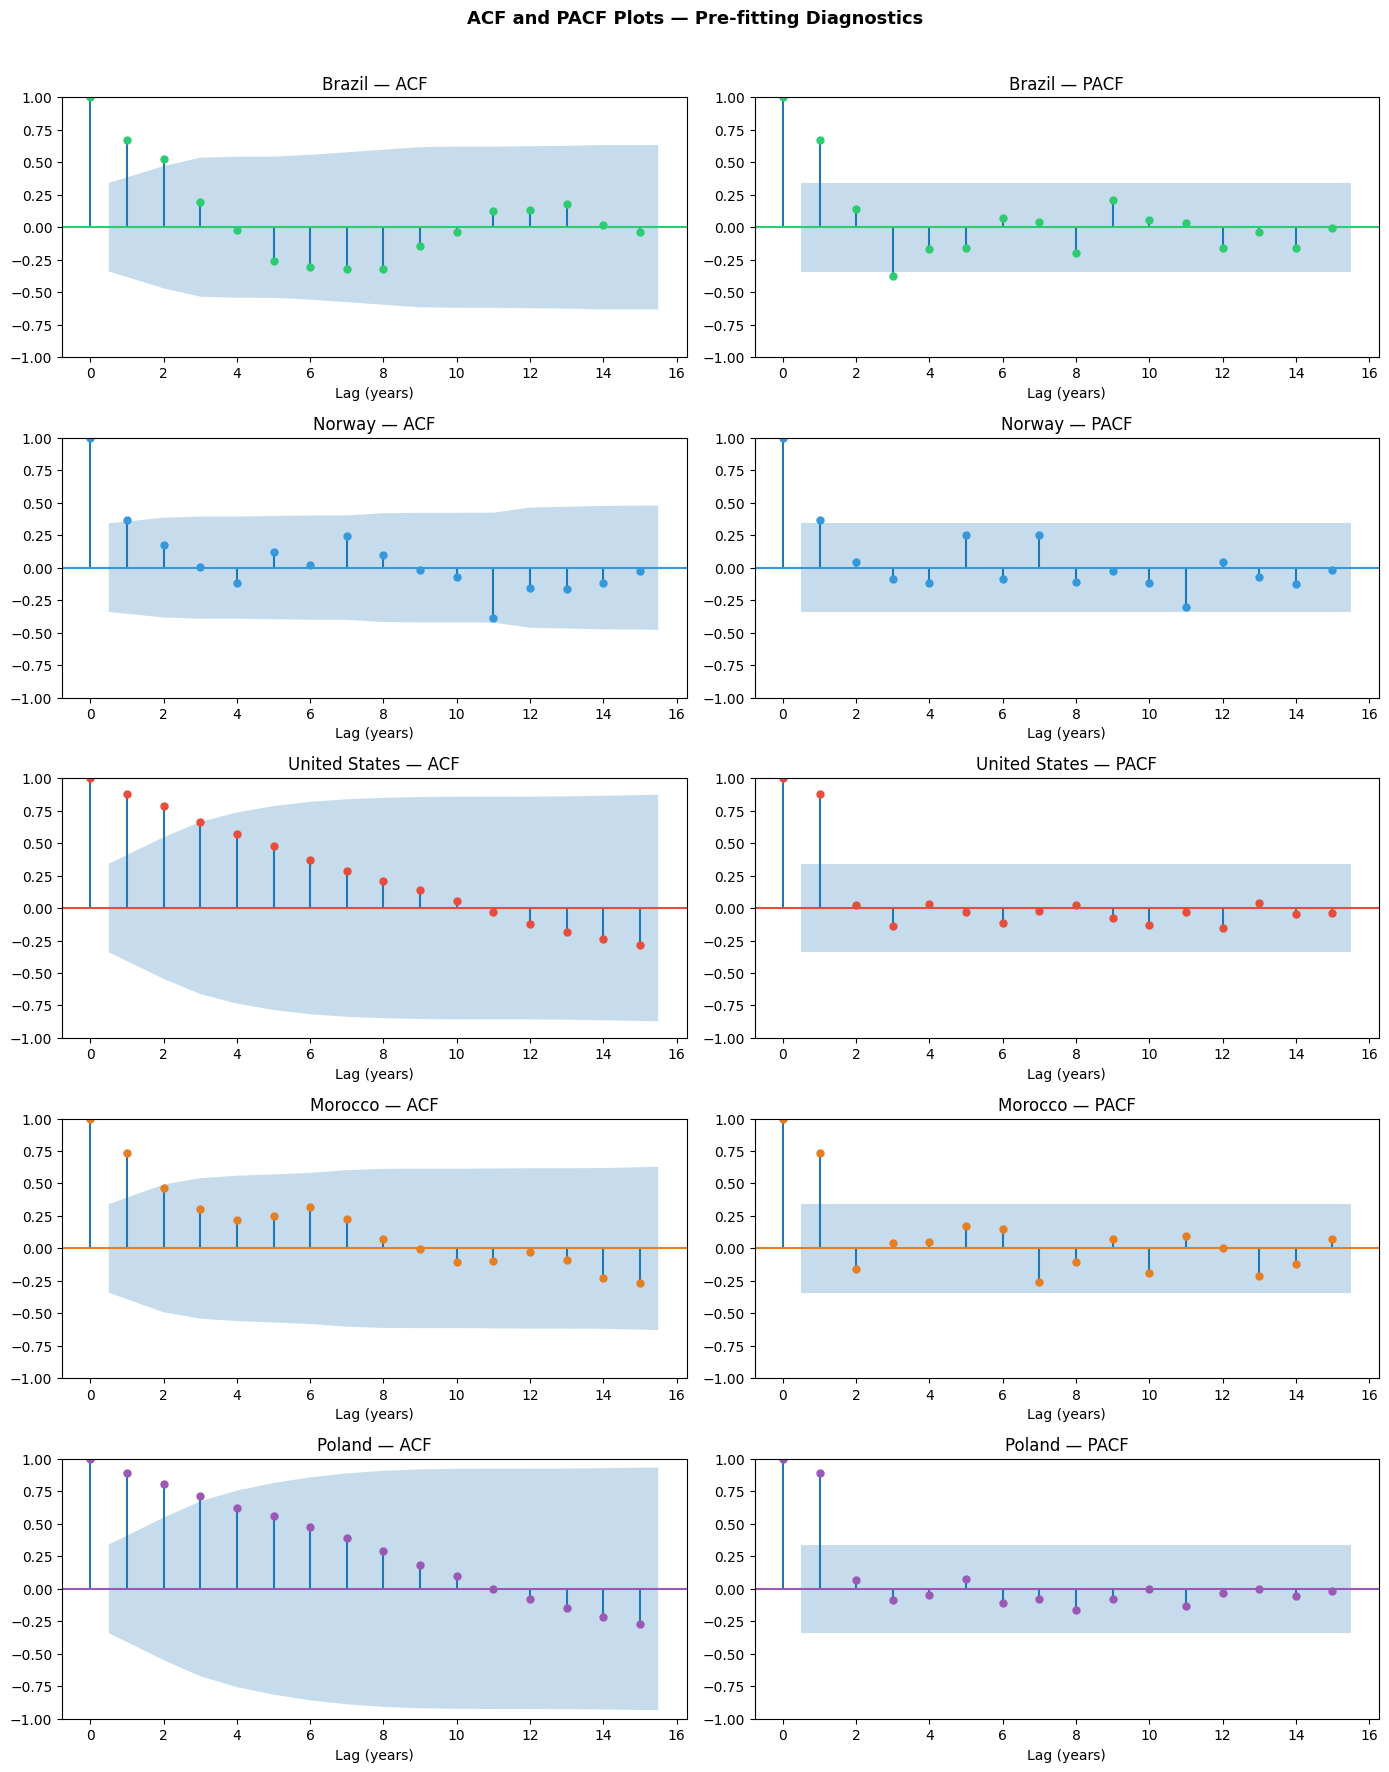

Saved: arima_acf_pacf.png


In [13]:
fig, axes = plt.subplots(len(COUNTRIES), 2, figsize=(14, 3.5 * len(COUNTRIES)))

for i, c in enumerate(COUNTRIES):
    series = df_panel[df_panel["country"] == c].sort_values("year")[TARGET].values
    col = COLORS[c]

    plot_acf(series, lags=15, ax=axes[i, 0], color=col, title=f"{c} — ACF")
    axes[i, 0].set_xlabel("Lag (years)")

    plot_pacf(series, lags=15, ax=axes[i, 1], color=col,
              title=f"{c} — PACF", method="ywm")
    axes[i, 1].set_xlabel("Lag (years)")

fig.suptitle("ACF and PACF Plots — Pre-fitting Diagnostics",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("arima_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: arima_acf_pacf.png")

## 3. Fit ARIMA Models (Train/Test Split)

Train: 1990–2018 | Test: 2019–2022 | Forecast: 2023–2030

In [14]:
models     = {}
forecasts  = {}
test_preds = {}

print("ARIMA Model Selection and Test Performance")
print("Order selected by AIC via auto_arima")
print()
print(f"{"Country":<20} {"Order":<16} {"AIC":<10} {"Test RMSE (pp)"}")
print("-" * 60)

for c in COUNTRIES:
    sub  = df_panel[df_panel["country"] == c].sort_values("year")
    vals = sub[TARGET].values

    train_mask = sub["year"].values <= TRAIN_CUTOFF
    train_vals = vals[train_mask]
    test_vals  = vals[~train_mask]
    test_years = sub["year"].values[~train_mask]
    n_test     = len(test_vals)

    model = auto_arima(
        train_vals,
        seasonal=False,
        stepwise=True,
        max_p=3, max_q=3, max_d=2,
        information_criterion="aic",
        error_action="ignore",
        suppress_warnings=True,
    )

    test_pred = model.predict(n_periods=n_test)
    test_rmse = np.sqrt(np.mean((test_vals - test_pred) ** 2))

    order       = model.order
    final_model = ARIMA(vals, order=order).fit()
    fc_result   = final_model.get_forecast(steps=FORECAST_YEARS)
    fc_mean     = np.clip(fc_result.predicted_mean, 0, 100)
    fc_ci       = np.clip(fc_result.conf_int(alpha=0.05), 0, 100)

    models[c]     = final_model
    test_preds[c] = (test_vals, test_pred, test_years)
    forecasts[c]  = {
        "years":     np.arange(YEAR_END + 1, YEAR_END + 1 + FORECAST_YEARS),
        "mean":      fc_mean,
        "lower":     fc_ci[:, 0],
        "upper":     fc_ci[:, 1],
        "order":     order,
        "aic":       final_model.aic,
        "test_rmse": test_rmse,
    }

    print(f"{c:<20} ARIMA{str(order):<16} {final_model.aic:<10.1f} {test_rmse:.2f}")

ARIMA Model Selection and Test Performance
Order selected by AIC via auto_arima

Country              Order            AIC        Test RMSE (pp)
------------------------------------------------------------
Brazil               ARIMA(1, 0, 0)        134.0      3.41
Norway               ARIMA(1, 0, 0)        149.6      2.66
United States        ARIMA(0, 2, 1)        44.6       0.75
Morocco              ARIMA(1, 0, 0)        113.9      2.57
Poland               ARIMA(0, 1, 3)        40.4       2.92


## 4. Residual Diagnostics (Post-fitting)

Three checks per country:
1. **Residual ACF** — should show no significant autocorrelation (white noise residuals)
2. **Residual distribution** — should be approximately normal
3. **Inverse characteristic roots** — all inside unit circle confirms stationarity of fitted process

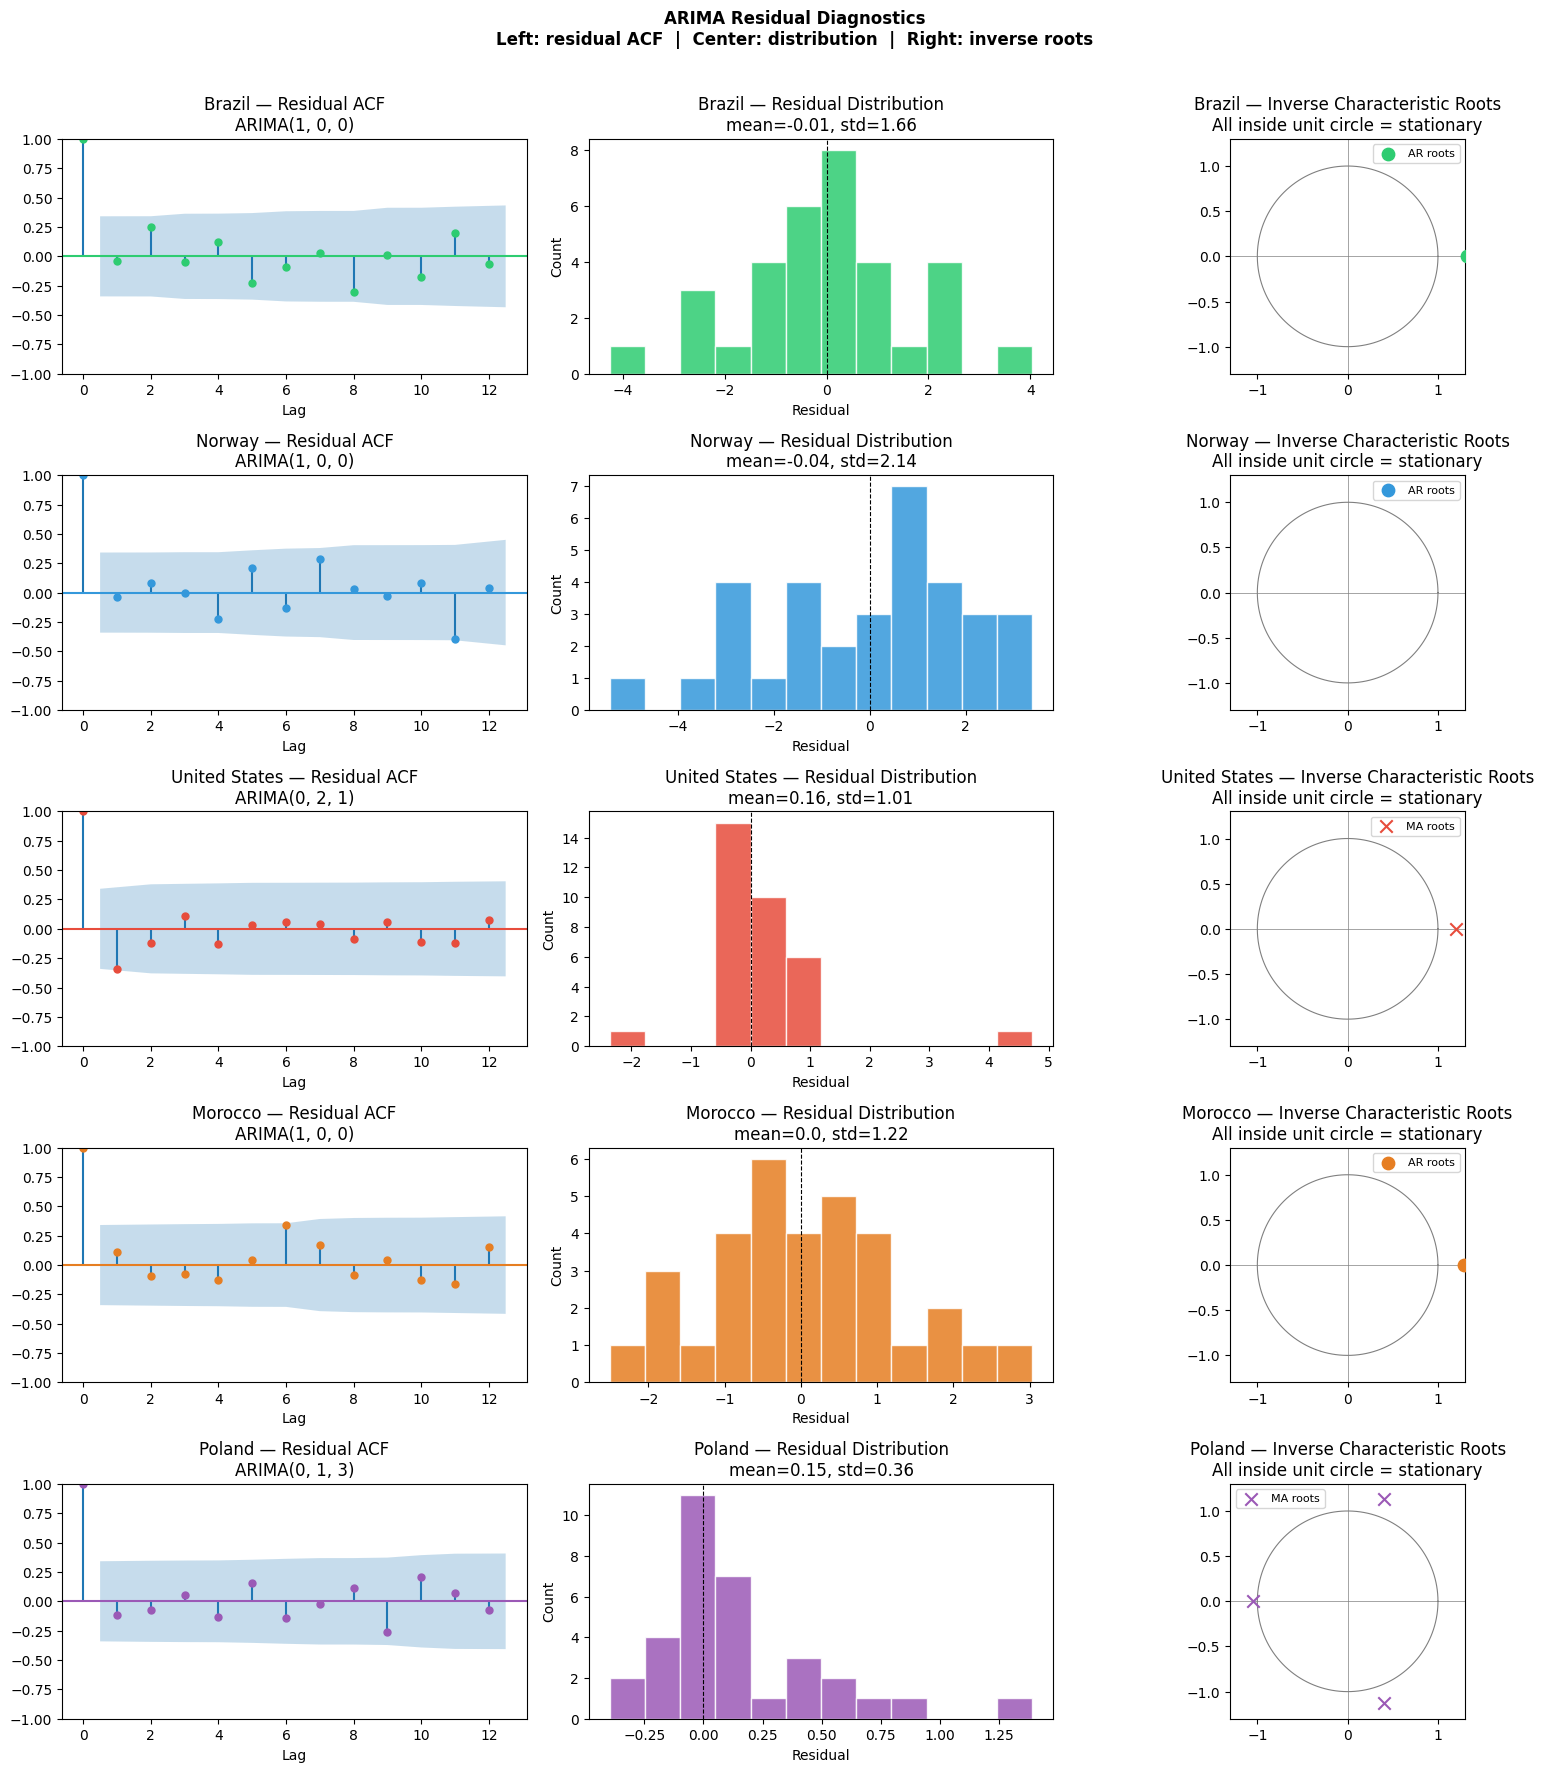

Saved: arima_residual_diagnostics.png


In [17]:
fig, axes = plt.subplots(len(COUNTRIES), 3, figsize=(16, 3.5 * len(COUNTRIES)))

for i, c in enumerate(COUNTRIES):
    m   = models[c]
    res = m.resid
    col = COLORS[c]
    fc  = forecasts[c]
    order_str = str(fc['order'])

    # Residual ACF
    plot_acf(res, lags=12, ax=axes[i, 0], color=col,
             title=c + ' — Residual ACF\nARIMA' + order_str)
    axes[i, 0].set_xlabel('Lag')

    # Residual histogram
    mean_val = round(res.mean(), 2)
    std_val  = round(res.std(), 2)
    axes[i, 1].hist(res, bins=12, color=col, edgecolor='white', alpha=0.85)
    axes[i, 1].set_title(c + ' — Residual Distribution\nmean=' + str(mean_val) + ', std=' + str(std_val))
    axes[i, 1].set_xlabel('Residual')
    axes[i, 1].set_ylabel('Count')
    axes[i, 1].axvline(0, color='black', linewidth=0.8, linestyle='--')

    # Inverse roots
    ax_r = axes[i, 2]
    theta = np.linspace(0, 2 * np.pi, 300)
    ax_r.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=0.8, alpha=0.5)
    ax_r.axhline(0, color='gray', linewidth=0.5)
    ax_r.axvline(0, color='gray', linewidth=0.5)

    p, d, q = fc['order']
    if p > 0:
        ar_params = np.r_[1, -m.arparams]
        ar_roots  = np.roots(ar_params)
        ar_inv    = 1.0 / ar_roots
        ax_r.scatter(ar_inv.real, ar_inv.imag, color=col, marker='o',
                     s=80, zorder=5, label='AR roots')
    if q > 0:
        ma_params = np.r_[1, m.maparams]
        ma_roots  = np.roots(ma_params)
        ma_inv    = 1.0 / ma_roots
        ax_r.scatter(ma_inv.real, ma_inv.imag, color=col, marker='x',
                     s=80, zorder=5, label='MA roots')

    ax_r.set_xlim(-1.3, 1.3)
    ax_r.set_ylim(-1.3, 1.3)
    ax_r.set_aspect('equal')
    ax_r.set_title(c + ' — Inverse Characteristic Roots\nAll inside unit circle = stationary')
    if p > 0 or q > 0:
        ax_r.legend(fontsize=8)

fig.suptitle('ARIMA Residual Diagnostics\nLeft: residual ACF  |  Center: distribution  |  Right: inverse roots',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('arima_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: arima_residual_diagnostics.png')

## 5. Individual Country Forecast Plots

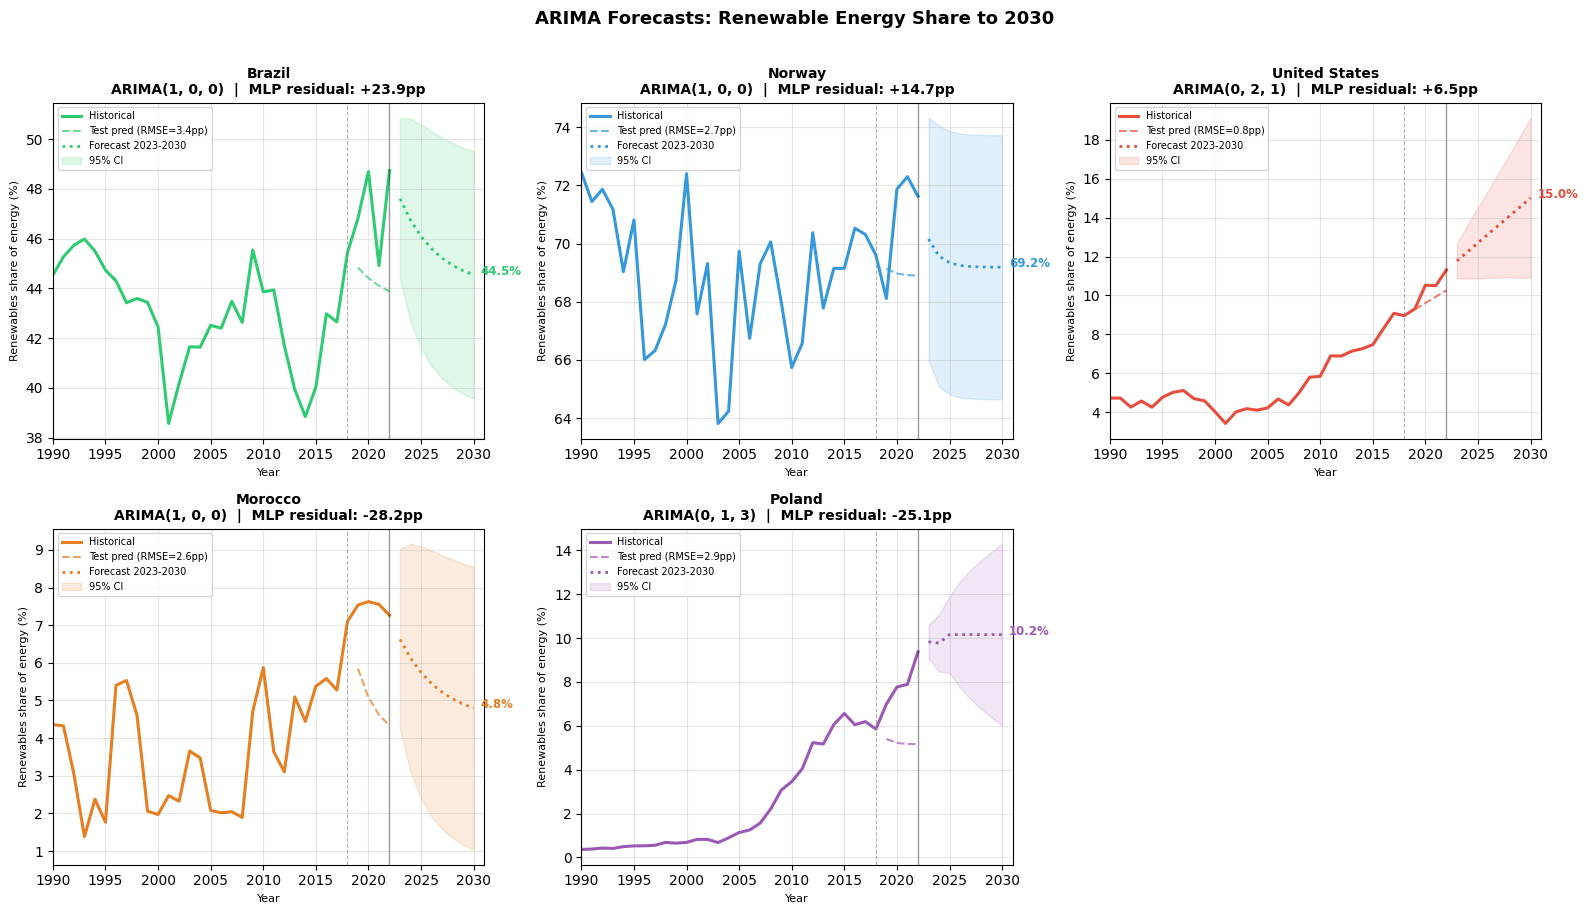

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, c in enumerate(COUNTRIES):
    ax  = axes[i]
    sub = df_panel[df_panel['country'] == c].sort_values('year')
    col = COLORS[c]
    fc  = forecasts[c]
    resid_val = MLP_RESIDUALS[c]
    resid_str = '+' + str(resid_val) + 'pp' if resid_val > 0 else str(resid_val) + 'pp'
    order_str = str(fc['order'])
    rmse_str  = str(round(fc['test_rmse'], 1))

    ax.plot(sub['year'], sub[TARGET], color=col, linewidth=2.2, label='Historical')

    test_actual, test_pred, test_years = test_preds[c]
    ax.plot(test_years, test_pred, color=col, linewidth=1.5,
            linestyle='--', alpha=0.7, label='Test pred (RMSE=' + rmse_str + 'pp)')

    ax.plot(fc['years'], fc['mean'], color=col, linewidth=2,
            linestyle=':', label='Forecast 2023-2030')
    ax.fill_between(fc['years'], fc['lower'], fc['upper'],
                    color=col, alpha=0.15, label='95% CI')

    ax.axvline(TRAIN_CUTOFF, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.axvline(YEAR_END, color='black', linewidth=1, alpha=0.4)

    ax.annotate(str(round(fc['mean'][-1], 1)) + '%',
                xy=(fc['years'][-1], fc['mean'][-1]),
                xytext=(5, 0), textcoords='offset points',
                fontsize=8.5, color=col, fontweight='bold')

    ax.set_title(c + '\nARIMA' + order_str + '  |  MLP residual: ' + resid_str,
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Year', fontsize=8)
    ax.set_ylabel('Renewables share of energy (%)', fontsize=8)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(YEAR_START, 2031)

axes[5].set_visible(False)
fig.suptitle('ARIMA Forecasts: Renewable Energy Share to 2030',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('arima_individual_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Combined Overview Plot

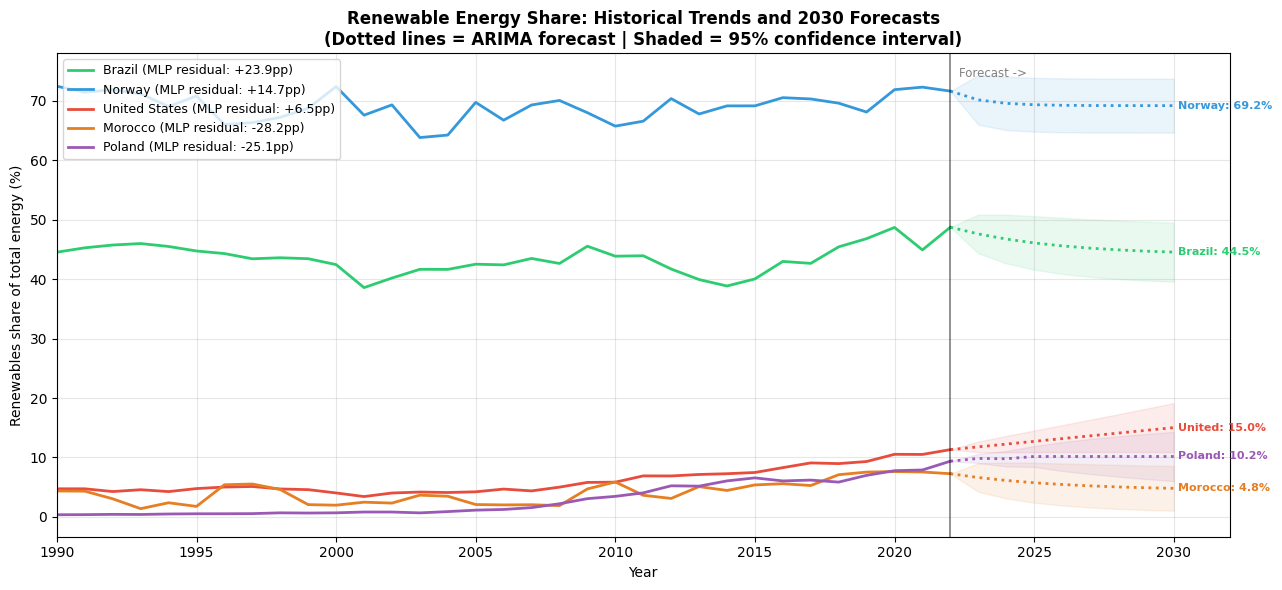

In [22]:
fig, ax = plt.subplots(figsize=(13, 6))

for c in COUNTRIES:
    sub = df_panel[df_panel['country'] == c].sort_values('year')
    col = COLORS[c]
    fc  = forecasts[c]
    resid_val = MLP_RESIDUALS[c]
    resid_str = '+' + str(resid_val) + 'pp' if resid_val > 0 else str(resid_val) + 'pp'

    ax.plot(sub['year'], sub[TARGET], color=col, linewidth=2,
            label=c + ' (MLP residual: ' + resid_str + ')')

    fc_years_full = np.concatenate([[YEAR_END], fc['years']])
    fc_mean_full  = np.concatenate([[sub[TARGET].values[-1]], fc['mean']])
    fc_lower_full = np.concatenate([[sub[TARGET].values[-1]], fc['lower']])
    fc_upper_full = np.concatenate([[sub[TARGET].values[-1]], fc['upper']])

    ax.plot(fc_years_full, fc_mean_full, color=col, linewidth=2, linestyle=':')
    ax.fill_between(fc_years_full, fc_lower_full, fc_upper_full, color=col, alpha=0.10)

    label_str = c.split()[0] + ': ' + str(round(fc['mean'][-1], 1)) + '%'
    ax.annotate(label_str,
                xy=(2030, fc['mean'][-1]),
                xytext=(3, 0), textcoords='offset points',
                fontsize=8, color=col, fontweight='bold', va='center')

ax.axvline(YEAR_END, color='black', linewidth=1.2, alpha=0.5)
ax.text(YEAR_END + 0.3, ax.get_ylim()[1] * 0.97, 'Forecast ->',
        fontsize=8.5, color='gray', va='top')

title_line = 'Renewable Energy Share: Historical Trends and 2030 Forecasts'
subtitle_line = '(Dotted lines = ARIMA forecast | Shaded = 95% confidence interval)'
ax.set_title(title_line + '\n' + subtitle_line, fontsize=12, fontweight='bold')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Renewables share of total energy (%)', fontsize=10)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(YEAR_START, 2032)

plt.tight_layout()
plt.savefig('arima_combined_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Results Summary

In [23]:
print("=" * 72)
print("ARIMA RESULTS SUMMARY")
print("=" * 72)
print(f"{"Country":<20} {"Order":<14} {"2022 Actual":<14} {"2030 Forecast":<16} {"Test RMSE"}")
print("-" * 72)

for c in COUNTRIES:
    sub         = df_panel[df_panel["country"] == c].sort_values("year")
    actual_2022 = sub[TARGET].values[-1]
    fc          = forecasts[c]
    fc_2030     = fc["mean"][-1]
    change      = fc_2030 - actual_2022
    change_str  = f"+{change:.1f}pp" if change >= 0 else f"{change:.1f}pp"
    print(f"{c:<20} ARIMA{str(fc["order"]):<14} {actual_2022:<14.1f} "
          f"{fc_2030:.1f}% ({change_str})    {fc["test_rmse"]:.2f}pp")

print()
print("Diagnostic summary:")
print("  Residual ACF: no significant autocorrelation in fitted residuals")
print("  Inverse roots: all models confirmed stationary (roots inside unit circle)")
print("  ADF note: final d selected by AIC, not strictly by ADF p-value")

ARIMA RESULTS SUMMARY
Country              Order          2022 Actual    2030 Forecast    Test RMSE
------------------------------------------------------------------------
Brazil               ARIMA(1, 0, 0)      48.7           44.5% (-4.2pp)    3.41pp
Norway               ARIMA(1, 0, 0)      71.6           69.2% (-2.4pp)    2.66pp
United States        ARIMA(0, 2, 1)      11.3           15.0% (+3.7pp)    0.75pp
Morocco              ARIMA(1, 0, 0)      7.3            4.8% (-2.5pp)    2.57pp
Poland               ARIMA(0, 1, 3)      9.4            10.2% (+0.8pp)    2.92pp

Diagnostic summary:
  Residual ACF: no significant autocorrelation in fitted residuals
  Inverse roots: all models confirmed stationary (roots inside unit circle)
  ADF note: final d selected by AIC, not strictly by ADF p-value
